In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, f1_score)

from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RAW_PATH = "loan_prediction.csv"

In [2]:
df_raw = pd.read_csv(RAW_PATH)

print("Shape:", df_raw.shape)
print("\nDtypes:\n", df_raw.dtypes)
print("\nMissing values:\n", df_raw.isnull().sum())
print("\nSummary stats (numeric):\n", df_raw.describe())
print("\nTarget balance:\n", df_raw["Loan_Status"].value_counts(normalize=True))
df_raw.head()

Shape: (614, 13)

Dtypes:
 Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Missing values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Summary stats (numeric):
        ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


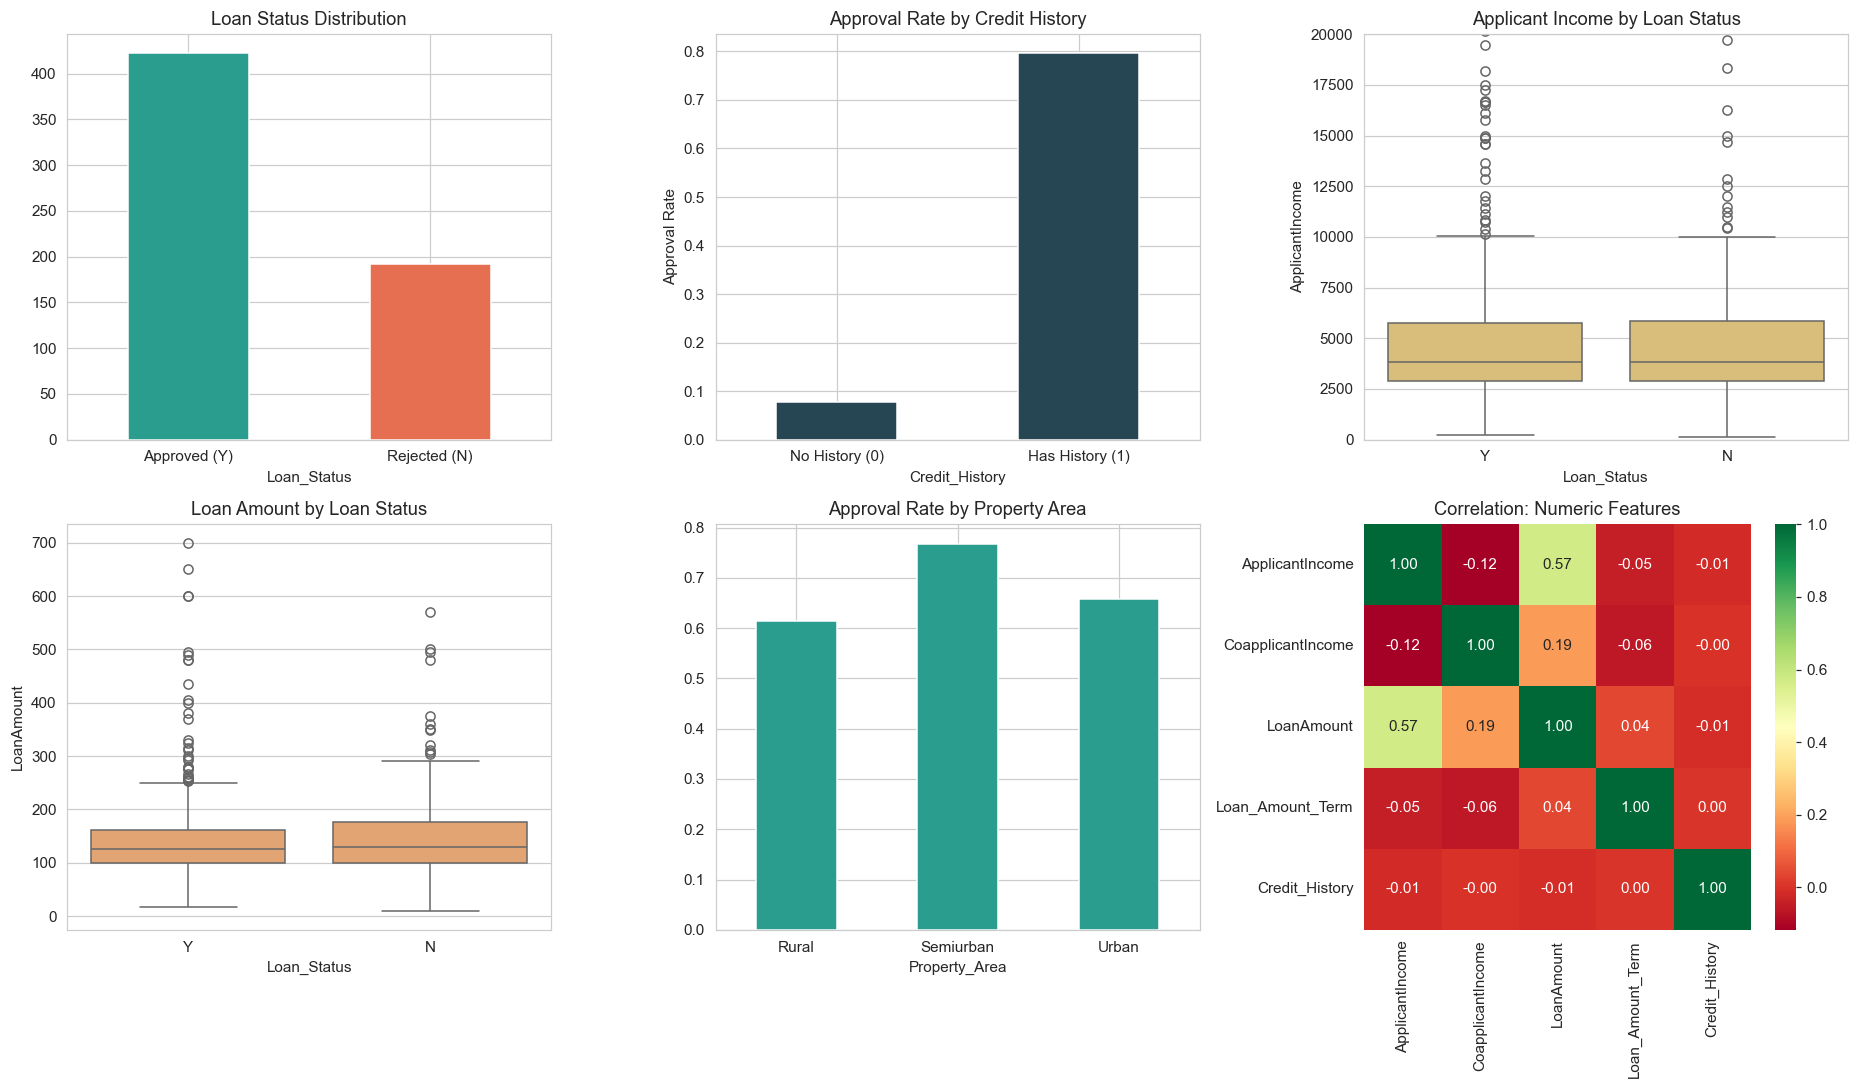

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Target class balance
df_raw["Loan_Status"].value_counts().plot(kind="bar", ax=axes[0,0], color=["#2a9d8f","#e76f51"])
axes[0,0].set_title("Loan Status Distribution")
axes[0,0].set_xticklabels(["Approved (Y)", "Rejected (N)"], rotation=0)

# Credit History vs Approval rate — the headline relationship
credit_approval = df_raw.groupby("Credit_History")["Loan_Status"].apply(lambda s: (s == "Y").mean())
credit_approval.plot(kind="bar", ax=axes[0,1], color="#264653")
axes[0,1].set_title("Approval Rate by Credit History")
axes[0,1].set_ylabel("Approval Rate")
axes[0,1].set_xticklabels(["No History (0)", "Has History (1)"], rotation=0)

# Applicant income distribution by status
sns.boxplot(data=df_raw, x="Loan_Status", y="ApplicantIncome", ax=axes[0,2], color="#e9c46a")
axes[0,2].set_title("Applicant Income by Loan Status")
axes[0,2].set_ylim(0, 20000)  # clip extreme outliers for readability

# Loan amount distribution by status
sns.boxplot(data=df_raw, x="Loan_Status", y="LoanAmount", ax=axes[1,0], color="#f4a261")
axes[1,0].set_title("Loan Amount by Loan Status")

# Approval rate by Property Area
area_approval = df_raw.groupby("Property_Area")["Loan_Status"].apply(lambda s: (s == "Y").mean())
area_approval.plot(kind="bar", ax=axes[1,1], color="#2a9d8f")
axes[1,1].set_title("Approval Rate by Property Area")
axes[1,1].tick_params(axis="x", rotation=0)

# Correlation heatmap of numeric features
num_cols = ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term","Credit_History"]
sns.heatmap(df_raw[num_cols].corr(), annot=True, fmt=".2f", cmap="RdYlGn", ax=axes[1,2])
axes[1,2].set_title("Correlation: Numeric Features")

plt.tight_layout()
plt.savefig("eda_overview.png")
plt.show()

In [4]:
readme_text = f"""# Loan Approval Prediction — Dataset & Initial Observations

## Dataset
Source: Kaggle — bhanupratapbiswas/loan-approval-prediction-case-study
Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}
Target: Loan_Status (Y = approved, N = rejected)

## Initial Observations
- Class balance: {(df_raw['Loan_Status']=='Y').mean():.1%} approved vs {(df_raw['Loan_Status']=='N').mean():.1%} rejected — moderate imbalance.
- Missing values present in 7 columns: Gender, Married, Dependents, Self_Employed,
  LoanAmount, Loan_Amount_Term, Credit_History (50 missing — the most of any column).
- Credit_History is the single strongest signal in the raw data: applicants WITH a
  credit history are approved {credit_approval[1]:.1%} of the time vs only
  {credit_approval[0]:.1%} for applicants WITHOUT one.
- Dependents contains a non-numeric category ('3+') that needs cleanup before modeling.
- Income and loan amount are right-skewed with high-end outliers (max income far
  above the median), which informs scaling choices for linear models.

## Next Steps
Preprocess (impute, encode, scale) -> handle class imbalance (SMOTE) ->
train Logistic Regression / Decision Tree / Random Forest -> evaluate on
precision, recall, F1, ROC-AUC -> pick a deployment threshold based on business cost.
"""
print(readme_text)

# Loan Approval Prediction — Dataset & Initial Observations

## Dataset
Source: Kaggle — bhanupratapbiswas/loan-approval-prediction-case-study
Rows: 614, Columns: 13
Target: Loan_Status (Y = approved, N = rejected)

## Initial Observations
- Class balance: 68.7% approved vs 31.3% rejected — moderate imbalance.
- Missing values present in 7 columns: Gender, Married, Dependents, Self_Employed,
  LoanAmount, Loan_Amount_Term, Credit_History (50 missing — the most of any column).
- Credit_History is the single strongest signal in the raw data: applicants WITH a
  credit history are approved 79.6% of the time vs only
  7.9% for applicants WITHOUT one.
- Dependents contains a non-numeric category ('3+') that needs cleanup before modeling.
- Income and loan amount are right-skewed with high-end outliers (max income far
  above the median), which informs scaling choices for linear models.

## Next Steps
Preprocess (impute, encode, scale) -> handle class imbalance (SMOTE) ->
train Logistic Regr

In [5]:
df = df_raw.drop(columns=["Loan_ID"]).copy()

df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

df["Dependents"] = df["Dependents"].replace("3+", "3")
df["Dependents"] = pd.to_numeric(df["Dependents"], errors="coerce")

cat_cols = ["Gender", "Married", "Education", "Self_Employed", "Property_Area"]
num_cols = ["Dependents", "ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]

for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

print("Missing values after imputation:", df.isnull().sum().sum())

df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_enc.drop(columns=["Loan_Status"])
y = df_enc["Loan_Status"]
print("Feature matrix:", X.shape)

Missing values after imputation: 0
Feature matrix: (614, 12)


In [6]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, stratify=y, random_state=42)

# Scale numeric features
scaler = StandardScaler()
num_present = [c for c in num_cols if c in X_train.columns]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_present] = scaler.fit_transform(X_train[num_present])
X_test_scaled[num_present] = scaler.transform(X_test[num_present])

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))

Train: (491, 12) | Test: (123, 12)
Train class balance:
 Loan_Status
1    0.686354
0    0.313646
Name: proportion, dtype: float64


In [7]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_sm.value_counts().to_dict())

Before SMOTE: {1: 337, 0: 154}
After SMOTE:  {1: 337, 0: 337}


In [8]:
models = {
    "Logistic Regression (class_weight)": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Logistic Regression (SMOTE)":        LogisticRegression(max_iter=1000),
    "Decision Tree (SMOTE)":              DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest (SMOTE)":              RandomForestClassifier(n_estimators=200, random_state=42),
}

results = []
fitted_models = {}

for name, model in models.items():
    if "SMOTE" in name:
        model.fit(X_train_sm, y_train_sm)
    else:
        model.fit(X_train_scaled, y_train)
    fitted_models[name] = model

    proba = model.predict_proba(X_test_scaled)[:, 1]
    pred = model.predict(X_test_scaled)

    report = classification_report(y_test, pred, output_dict=True)
    results.append({
        "Model": name,
        "Precision (approved)": report["1"]["precision"],
        "Recall (approved)":    report["1"]["recall"],
        "F1 (approved)":        report["1"]["f1-score"],
        "Precision (rejected)": report["0"]["precision"],
        "Recall (rejected)":    report["0"]["recall"],
        "F1 (rejected)":        report["0"]["f1-score"],
        "ROC-AUC":              roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
print(results_df)

                                    Precision (approved)  Recall (approved)  \
Model                                                                         
Logistic Regression (class_weight)                 0.862              0.882   
Logistic Regression (SMOTE)                        0.840              0.929   
Decision Tree (SMOTE)                              0.806              0.682   
Random Forest (SMOTE)                              0.852              0.882   

                                    F1 (approved)  Precision (rejected)  \
Model                                                                     
Logistic Regression (class_weight)          0.872                 0.722   
Logistic Regression (SMOTE)                 0.883                 0.793   
Decision Tree (SMOTE)                       0.739                 0.471   
Random Forest (SMOTE)                       0.867                 0.714   

                                    Recall (rejected)  F1 (rejected)  ROC-

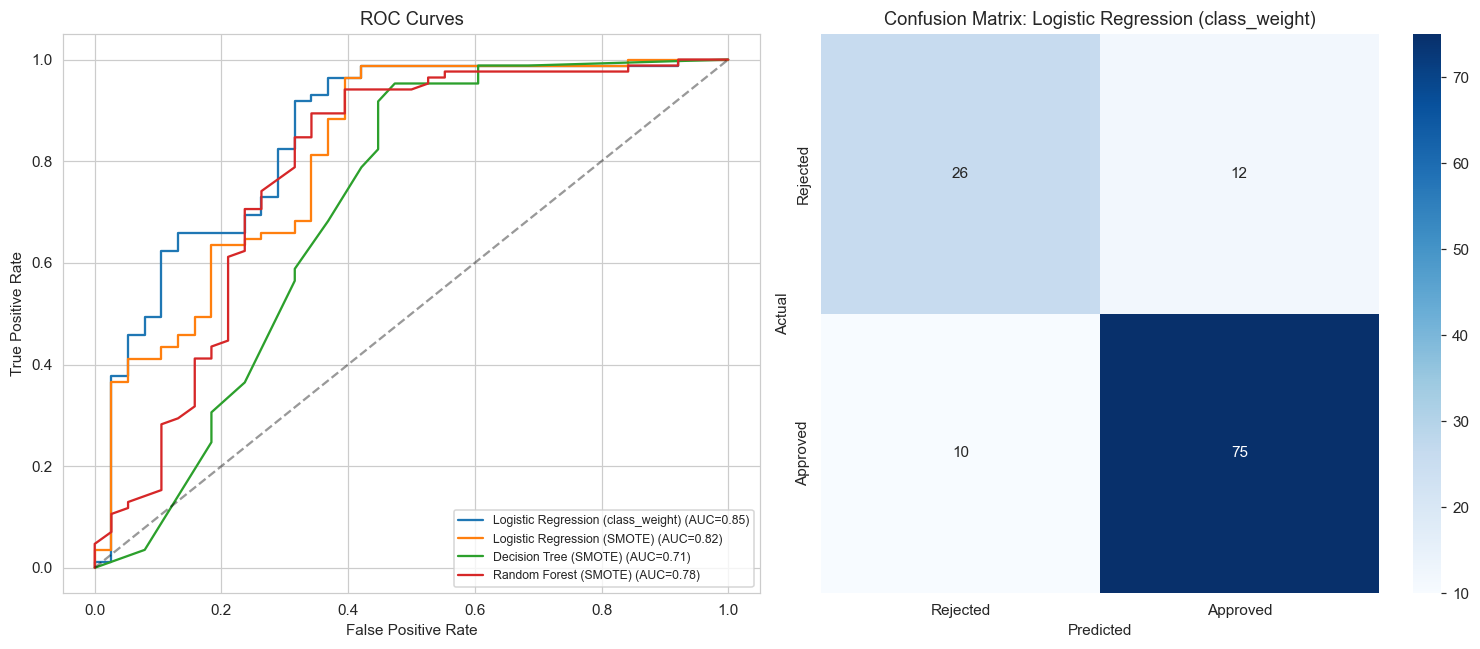

Best model by ROC-AUC: Logistic Regression (class_weight)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, model in fitted_models.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.2f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend(fontsize=8)

best_model_name = results_df["ROC-AUC"].idxmax()
best_model = fitted_models[best_model_name]
pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Rejected", "Approved"], yticklabels=["Rejected", "Approved"])
axes[1].set_title(f"Confusion Matrix: {best_model_name}")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

print(f"Best model by ROC-AUC: {best_model_name}")

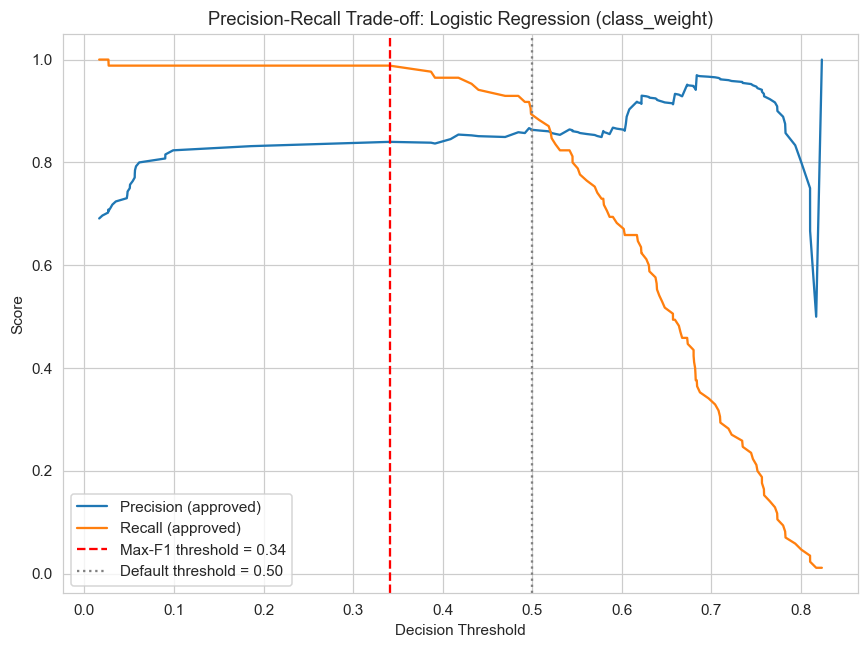

Threshold that maximizes F1: 0.341
At default 0.5:   Precision=0.864, Recall=0.894


In [10]:
proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, proba_best)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(thresholds, precisions[:-1], label="Precision (approved)")
ax.plot(thresholds, recalls[:-1], label="Recall (approved)")
ax.axvline(best_f1_threshold, color="red", linestyle="--", label=f"Max-F1 threshold = {best_f1_threshold:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="Default threshold = 0.50")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Precision-Recall Trade-off: {best_model_name}")
ax.legend()
plt.tight_layout()
plt.savefig("threshold_tuning.png")
plt.show()

print(f"Threshold that maximizes F1: {best_f1_threshold:.3f}")
print(f"At default 0.5:   Precision={precisions[np.argmin(np.abs(thresholds-0.5))]:.3f}, "f"Recall={recalls[np.argmin(np.abs(thresholds-0.5))]:.3f}")

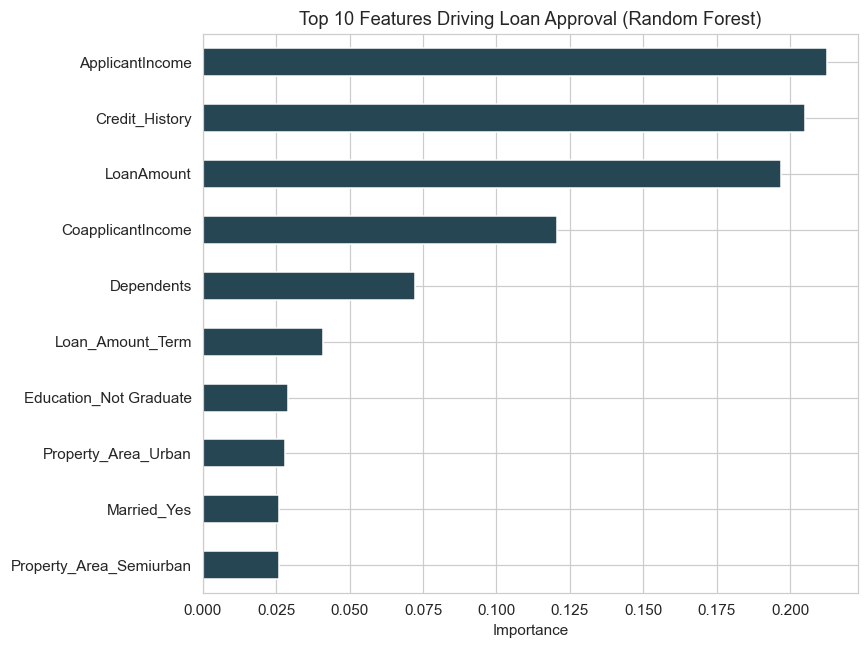

ApplicantIncome            0.212448
Credit_History             0.205022
LoanAmount                 0.196881
CoapplicantIncome          0.120547
Dependents                 0.072373
Loan_Amount_Term           0.041052
Education_Not Graduate     0.029184
Property_Area_Urban        0.027919
Married_Yes                0.026053
Property_Area_Semiurban    0.025928
dtype: float64


In [11]:
rf_model = fitted_models.get("Random Forest (SMOTE)")
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(10).sort_values().plot(kind="barh", ax=ax, color="#264653")
ax.set_title("Top 10 Features Driving Loan Approval (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance_loan.png")
plt.show()

print(importances.head(10))

In [12]:
report_text = f"""
LOAN APPROVAL MODEL — TRADE-OFFS & DEPLOYMENT RECOMMENDATION
==============================================================

MODEL COMPARISON
{results_df.to_string()}

KEY TRADE-OFFS
- Logistic Regression (class_weight='balanced') vs SMOTE-based Logistic Regression:
  class_weight tends to give higher recall on the minority class (rejections) at
  some cost to precision, since it never fabricates synthetic points — it simply
  reweights the loss. SMOTE can overfit synthetic minority patterns on a dataset
  this small (614 rows), so treat SMOTE results with slightly more caution here.
- Tree-based models (Decision Tree, Random Forest) capture non-linear interactions
  (e.g. Credit_History combined with income) that Logistic Regression cannot, but
  on a dataset this size they are more prone to variance — Random Forest is the
  more stable of the two.
- Best model by ROC-AUC: {best_model_name} (AUC = {results_df.loc[best_model_name, 'ROC-AUC']:.3f}).

BUSINESS INTERPRETATION
- Credit_History is overwhelmingly the dominant signal: applicants with a credit
  history are approved {credit_approval[1]:.1%} of the time vs {credit_approval[0]:.1%}
  without one. Any deployed model should be explainable in these terms to loan
  officers and applicants (regulatory/fair-lending expectation, not just a
  data-science nicety).
- A false positive (approving a loan that should be rejected) carries direct credit
  risk / default cost. A false negative (rejecting a loan that should be approved)
  carries opportunity cost and applicant harm, but no direct financial loss.
  Because the downside of a bad approval is typically larger than the downside of
  a good rejection, the deployment threshold should generally be set ABOVE the
  default 0.5, not at the F1-maximizing point, unless the lender explicitly wants
  to prioritize approval volume over risk.

RECOMMENDED THRESHOLD
- F1-maximizing threshold on the held-out test set: {best_f1_threshold:.2f}.
- For a risk-conscious deployment, consider starting slightly higher (e.g.
  {min(best_f1_threshold + 0.05, 0.95):.2f}-{min(best_f1_threshold + 0.10, 0.95):.2f})
  and monitoring real-world default rates before tuning further — this is a
  business policy decision informed by the model, not purely a statistical one.
- Given the small dataset (614 rows), validate this threshold on more data before
  finalizing it for production use; current precision/recall estimates have
  meaningful uncertainty at this sample size.
"""
print(report_text)


LOAN APPROVAL MODEL — TRADE-OFFS & DEPLOYMENT RECOMMENDATION

MODEL COMPARISON
                                    Precision (approved)  Recall (approved)  F1 (approved)  Precision (rejected)  Recall (rejected)  F1 (rejected)  ROC-AUC
Model                                                                                                                                                      
Logistic Regression (class_weight)                 0.862              0.882          0.872                 0.722              0.684          0.703    0.853
Logistic Regression (SMOTE)                        0.840              0.929          0.883                 0.793              0.605          0.687    0.816
Decision Tree (SMOTE)                              0.806              0.682          0.739                 0.471              0.632          0.539    0.706
Random Forest (SMOTE)                              0.852              0.882          0.867                 0.714              0.658         